In [ ]:
from ipywidgets import interact
import matplotlib.pyplot as plt
import torch

print(plt.style.available)

plt.style.use("seaborn-v0_8-dark-palette")


In [ ]:
from ipywidgets import interact
from fastai.basics import *

plt.rc('figure', dpi=90)

def plot_function(f, title=None, min=-2.1, max=2.1, color='r', ylim=None):
    x = torch.linspace(min,max, 100)[:,None]
    if ylim: plt.ylim(ylim)
    plt.plot(x, f(x), color)
    if title is not None: plt.title(title)

In [5]:
def quad(a, b, c, x): return a*x**2 + b*x + c
quad(3,2,1,1.5)


10.75

In [6]:
from functools import partial
def mk_quad(a, b, c): return partial(quad, a, b, c)

f = mk_quad(3,2,1)
f(1.5)


10.75

In [7]:
from matplotlib.pyplot import sca
from numpy.random import normal, seed, uniform

def noise(x, scale): return normal(scale=scale, size=x.shape)
def add_noise(x, mult, add): return x * (1+noise(x, mult)) + noise(x, add)


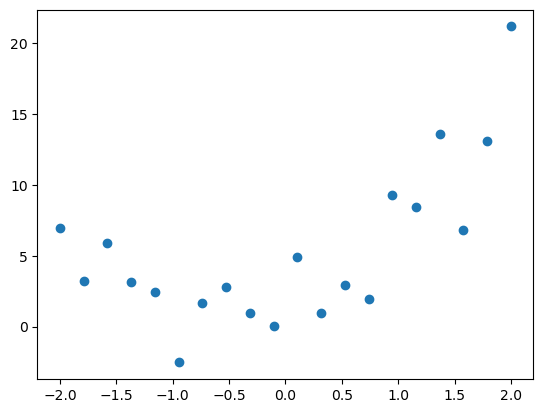

In [8]:
x = torch.linspace(-2, 2, steps=20)[:,None]
y = add_noise(f(x), 0.3, 1.5)
plt.scatter(x, y)


In [13]:

@interact(a = 1.5, b = 2, c = 0.5)
def plot_quadratic(a, b, c):
    plt.scatter(x, y)
    plot_function(mk_quad(a, b, c), ylim=(-3,12))


interactive(children=(FloatSlider(value=1.5, description='a', max=4.5, min=-1.5), IntSlider(value=2, descripti…

In [14]:
def mse(y_true, y_pred): return ((y_true - y_pred)**2).mean()


In [19]:
@interact(a = 1.5, b = 2.1, c = 0.5)
def plot_quadratic(a, b, c):
    plt.scatter(x, y)
    loss = mse(y, mk_quad(a, b, c)(x))
    plot_function(mk_quad(a, b, c), ylim=(-3,12), title=f'MSE: {loss:.2f}')

interactive(children=(FloatSlider(value=1.5, description='a', max=4.5, min=-1.5), FloatSlider(value=2.1, descr…

In [21]:
def quad_mse(params):
    f = mk_quad(*params)
    return mse(y, f(x))

quad_mse((1.5, 2.1, 0.5))

tensor(16.3008, dtype=torch.float64)

In [35]:
abc = torch.tensor([2.6, 2.1, 0.6])
abc.requires_grad_()


tensor([2.6000, 2.1000, 0.6000], requires_grad=True)

In [36]:
loss = quad_mse(abc)
loss

tensor(7.5051, dtype=torch.float64, grad_fn=<MeanBackward0>)

In [37]:
loss.backward()
abc.grad

tensor([-3.2310, -1.9018, -1.9312])

In [38]:
with torch.no_grad():
    abc -= abc.grad * 0.01
    loss = quad_mse(abc)

print(f'loss: {loss:.2f}')


loss: 7.33


In [48]:
for i in range(5):
    loss = quad_mse(abc)
    loss.backward()
    with torch.no_grad():
        abc -= abc.grad * 0.01
    print(f'step {i+1} loss: {loss:.2f}')

abc


step 1 loss: 6.56
step 2 loss: 6.46
step 3 loss: 6.47
step 4 loss: 6.58
step 5 loss: 6.72


tensor([2.5100, 3.0119, 0.8508], requires_grad=True)

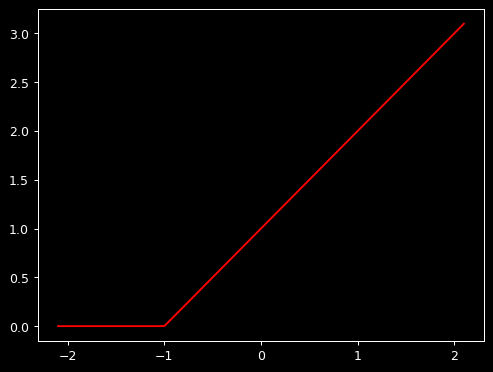

In [ ]:
def rectified_linear(m, b, x):
    y = m*x + b
    return torch.clip(y, 0.0)

plot_function(partial(rectified_linear, 1, 1))


In [58]:
@interact(m = 1.0, b = 1.0)
def plot_rectified_linear(m, b):
    plot_function(partial(rectified_linear, m, b))


interactive(children=(FloatSlider(value=1.0, description='m', max=3.0, min=-1.0), FloatSlider(value=1.0, descr…